In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset Shape:")
print(df.shape)

print("\nChurn Counts:")
print(df["Churn"].value_counts())

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(7043, 21)

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
customerID

In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

print("Encoded Data Types:")
print(df.dtypes)

Encoded Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [3]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 20)
y Shape: (7043,)


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5634, 20)
Testing Data Shape: (1409, 20)


In [5]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Model Trained Successfully!")

ValueError: could not convert string to float: '4223-BKEOR'

In [6]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'string':
        df[col] = le.fit_transform(df[col].astype(str))

print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [8]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [9]:
from sklearn.preprocessing import LabelEncoder

# Remove customerID first
df = df.drop("customerID", axis=1)

# Convert all text columns to numbers
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'str':
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col].astype(str))

print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
Churn                 int64
dtype: object


In [10]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [12]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:")
print(accuracy_score(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

Accuracy:
0.7274662881476224

Confusion Matrix:
[[855 181]
 [203 170]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1036
           1       0.48      0.46      0.47       373

    accuracy                           0.73      1409
   macro avg       0.65      0.64      0.64      1409
weighted avg       0.72      0.73      0.72      1409



In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
0.7977288857345636

Confusion Matrix:
[[949  87]
 [198 175]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [16]:
dt_acc = accuracy_score(y_test, tree_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Decision Tree Accuracy: 0.7274662881476224
Random Forest Accuracy: 0.7977288857345636


In [17]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

             Feature  Importance
17    MonthlyCharges    0.176906
4             tenure    0.173502
18      TotalCharges    0.168442
14          Contract    0.081254
16     PaymentMethod    0.051348
8     OnlineSecurity    0.048782
11       TechSupport    0.043704
9       OnlineBackup    0.027751
0             gender    0.027438
15  PaperlessBilling    0.025961


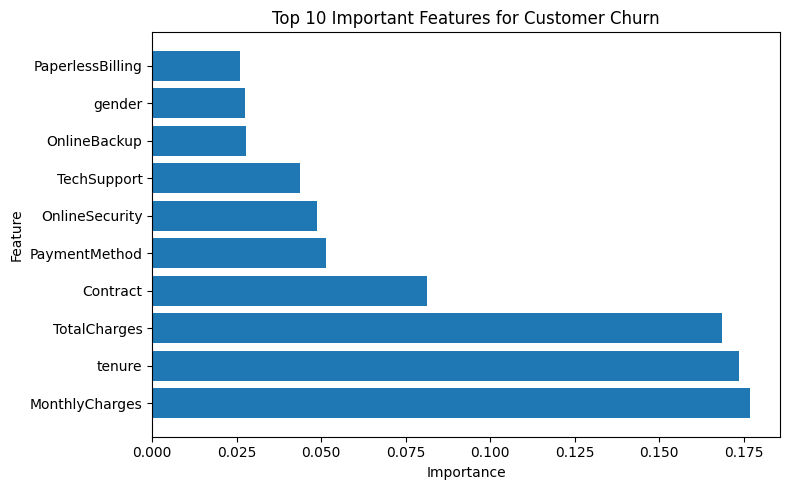

In [19]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features for Customer Churn")
plt.tight_layout()
plt.show()

In [20]:
print("PROJECT CONCLUSION")
print("------------------")
print("Random Forest achieved higher accuracy than Decision Tree.")
print("The most important factors affecting customer churn are:")
print("MonthlyCharges, Tenure, TotalCharges, Contract, and PaymentMethod.")
print("Therefore, Random Forest is the preferred model for customer churn prediction.")

PROJECT CONCLUSION
------------------
Random Forest achieved higher accuracy than Decision Tree.
The most important factors affecting customer churn are:
MonthlyCharges, Tenure, TotalCharges, Contract, and PaymentMethod.
Therefore, Random Forest is the preferred model for customer churn prediction.
